# Experiment 2: Hybrid GNN-XGBoost Architecture Comparison

**Research Question (RQ2)**: How does a hybrid GNN + XGBoost architecture compare to XGBoost with handcrafted graph features?

**Models Compared**:
- **XGBoost (standard)**: Handcrafted graph features (shared contacts, component size, PageRank)
- **SAGE Hybrid**: GraphSAGE embeddings (64-dim) + XGBoost
- **HGT Hybrid**: Heterogeneous Graph Transformer embeddings (64-dim) + XGBoost


In [7]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mlflow.tracking import MlflowClient

# Setup MLflow
mlflow.set_tracking_uri('sqlite:///../fraud-detection-mlflow.db')
client = MlflowClient()


## 1. Load Experiment Results from MLflow


In [8]:
# Experiment run IDs from MLflow
runs = {
    'XGBoost (standard)': '3b034513b8974653aa024c88a99571b4',
    'SAGE Hybrid': '6a263b115eba47e98790d46ad4f6bdfb',
    'HGT Hybrid': 'cf3c5edf66ab4b198cdc8dfe294ad2f9',
}

# Load parent run metrics
parent_metrics = []
for name, run_id in runs.items():
    run = client.get_run(run_id)
    parent_metrics.append({
        'Model': name,
        'Mean AUC-PR': run.data.metrics.get('mean_auc_pr'),
        'Best AUC-PR': run.data.metrics.get('best_auc_pr'),
        'Windows': int(run.data.metrics.get('num_windows', 0)),
        'Uses GNN': run.data.params.get('uses_gnn_embeddings'),
    })

parent_df = pd.DataFrame(parent_metrics)

# Calculate deltas vs baseline
baseline = parent_df.loc[0, 'Mean AUC-PR']
parent_df['Delta vs Standard'] = parent_df['Mean AUC-PR'] - baseline
parent_df['Relative (%)'] = (parent_df['Delta vs Standard'] / baseline * 100).round(2)

print("="*70)
print("EXPERIMENT 2: MODEL COMPARISON SUMMARY")
print("="*70)
display(parent_df)

print(f"\n📊 Key Results:")
print(f"   SAGE Hybrid: {parent_df.loc[1, 'Relative (%)']: >+.2f}% vs standard")
print(f"   HGT Hybrid:  {parent_df.loc[2, 'Relative (%)']: >+.2f}% vs standard")


EXPERIMENT 2: MODEL COMPARISON SUMMARY


,Model,Mean AUC-PR,Best AUC-PR,Windows,Uses GNN,Delta vs Standard,Relative (%)
0,XGBoost (standard),0.620012,0.864991,121,False,0.000000,0.00
1,SAGE Hybrid,0.630345,0.871596,121,True,0.010333,1.67
2,HGT Hybrid,0.618503,0.877136,121,True,-0.001509,-0.24



📊 Key Results:
   SAGE Hybrid: +1.67% vs standard
   HGT Hybrid:  -0.24% vs standard


## 2. Per-Window Performance Analysis


In [9]:
def get_child_metrics(parent_run_id, model_name):
    """Get metrics from all child (window) runs."""
    child_runs = client.search_runs(
        experiment_ids=['1'],
        filter_string=f"tags.mlflow.parentRunId = '{parent_run_id}'",
        max_results=150
    )
    
    metrics = []
    for run in child_runs:
        window_idx = run.data.params.get('window_index')
        if window_idx:
            metrics.append({
                'model': model_name,
                'window': int(window_idx),
                'auc_pr': run.data.metrics.get('auc_pr'),
                'auc_roc': run.data.metrics.get('auc_roc'),
                'p_at_100': run.data.metrics.get('p_at_100'),
            })
    
    return pd.DataFrame(metrics).sort_values('window')

# Get child metrics for all runs
child_dfs = []
for name, run_id in runs.items():
    df = get_child_metrics(run_id, name)
    child_dfs.append(df)
    print(f"{name}: {len(df)} child runs")

all_child_df = pd.concat(child_dfs, ignore_index=True)
print(f"\nTotal: {len(all_child_df)} window results")


XGBoost (standard): 121 child runs
SAGE Hybrid: 121 child runs
HGT Hybrid: 121 child runs

Total: 363 window results


In [10]:
# Merge per-window metrics for comparison
std = all_child_df[all_child_df['model'] == 'XGBoost (standard)'][['window', 'auc_pr']].rename(columns={'auc_pr': 'std_auc_pr'})
sage = all_child_df[all_child_df['model'] == 'SAGE Hybrid'][['window', 'auc_pr']].rename(columns={'auc_pr': 'sage_auc_pr'})
hgt = all_child_df[all_child_df['model'] == 'HGT Hybrid'][['window', 'auc_pr']].rename(columns={'auc_pr': 'hgt_auc_pr'})

merged = std.merge(sage, on='window').merge(hgt, on='window')

# Calculate improvement statistics
sage_diff = merged['sage_auc_pr'] - merged['std_auc_pr']
hgt_diff = merged['hgt_auc_pr'] - merged['std_auc_pr']

print("="*70)
print("PER-WINDOW IMPROVEMENT ANALYSIS")
print("="*70)

print(f"\nSAGE vs Standard:")
print(f"   Mean improvement:  {sage_diff.mean():+.4f}")
print(f"   Windows improved:  {(sage_diff > 0).sum()}/{len(merged)} ({(sage_diff > 0).mean()*100:.1f}%)")
print(f"   Max improvement:   {sage_diff.max():+.4f}")
print(f"   Max degradation:   {sage_diff.min():+.4f}")

print(f"\nHGT vs Standard:")
print(f"   Mean improvement:  {hgt_diff.mean():+.4f}")
print(f"   Windows improved:  {(hgt_diff > 0).sum()}/{len(merged)} ({(hgt_diff > 0).mean()*100:.1f}%)")
print(f"   Max improvement:   {hgt_diff.max():+.4f}")
print(f"   Max degradation:   {hgt_diff.min():+.4f}")


PER-WINDOW IMPROVEMENT ANALYSIS

SAGE vs Standard:
   Mean improvement:  +0.0103
   Windows improved:  105/121 (86.8%)
   Max improvement:   +0.0459
   Max degradation:   -0.0336

HGT vs Standard:
   Mean improvement:  -0.0015
   Windows improved:  63/121 (52.1%)
   Max improvement:   +0.0359
   Max degradation:   -0.0886


## 3. Visualization: GNN Hybrid vs Handcrafted Features


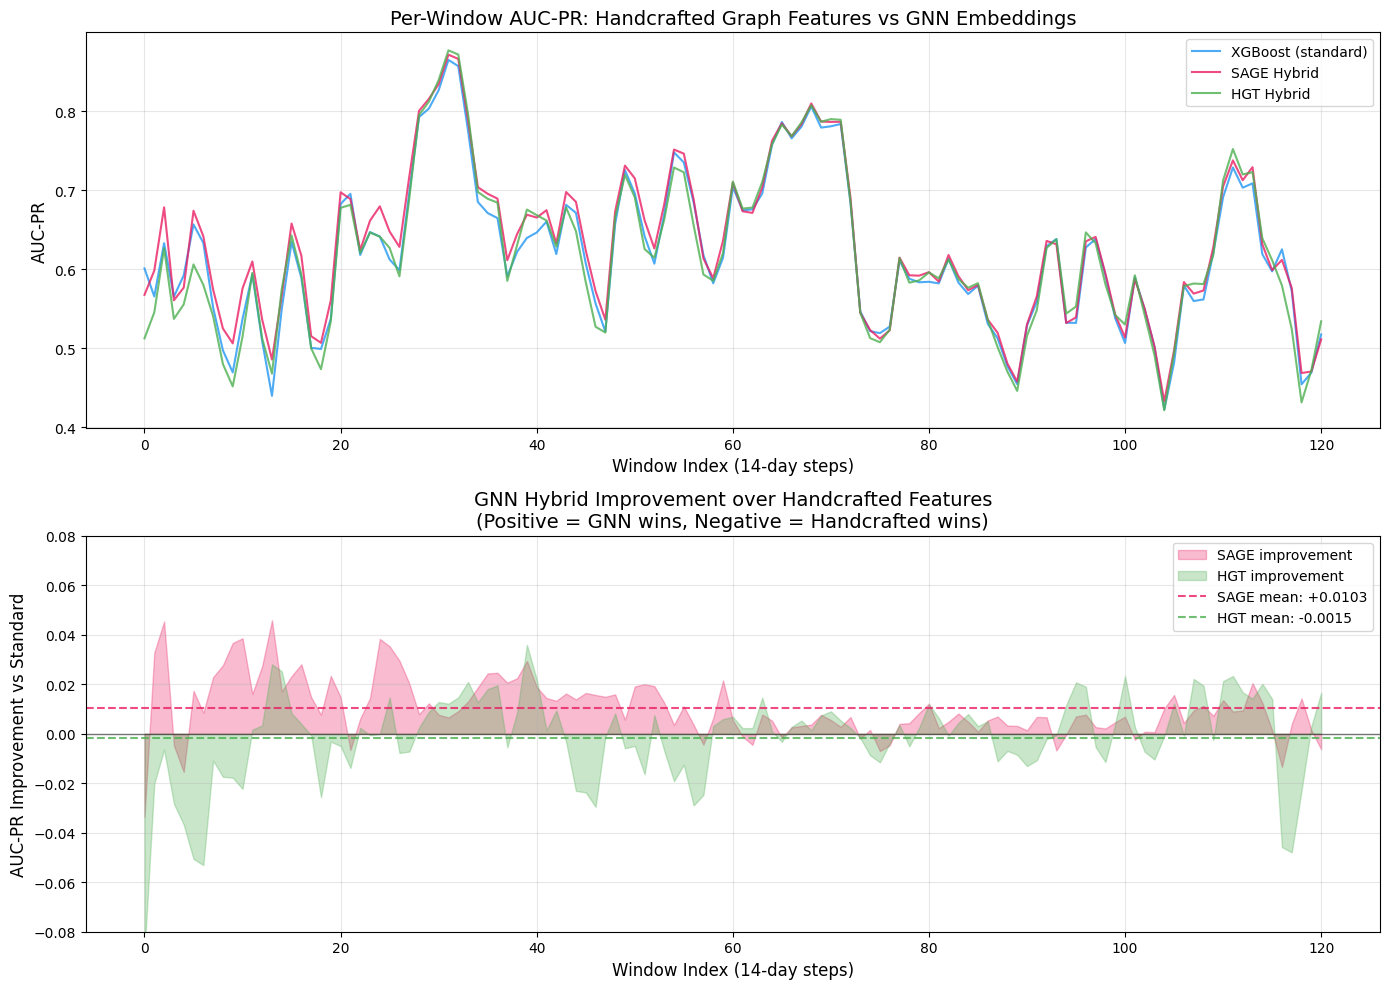


📊 Figure saved to artifacts/experiment2_comparison.png


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: AUC-PR over windows (all models)
ax1 = axes[0]
colors = {'XGBoost (standard)': '#2196F3', 'SAGE Hybrid': '#E91E63', 'HGT Hybrid': '#4CAF50'}
for model in runs.keys():
    model_df = all_child_df[all_child_df['model'] == model].sort_values('window')
    ax1.plot(model_df['window'], model_df['auc_pr'], 
             label=model, color=colors[model], alpha=0.8, linewidth=1.5)

ax1.set_xlabel('Window Index (14-day steps)', fontsize=12)
ax1.set_ylabel('AUC-PR', fontsize=12)
ax1.set_title('Per-Window AUC-PR: Handcrafted Graph Features vs GNN Embeddings', fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Plot 2: Difference from Standard (improvement/degradation)
ax2 = axes[1]
merged_sorted = merged.sort_values('window')
ax2.fill_between(merged_sorted['window'], 0, merged_sorted['sage_auc_pr'] - merged_sorted['std_auc_pr'], 
                  alpha=0.3, color='#E91E63', label='SAGE improvement')
ax2.fill_between(merged_sorted['window'], 0, merged_sorted['hgt_auc_pr'] - merged_sorted['std_auc_pr'], 
                  alpha=0.3, color='#4CAF50', label='HGT improvement')
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)

# Add mean lines
ax2.axhline(y=sage_diff.mean(), color='#E91E63', linestyle='--', alpha=0.8, 
            label=f'SAGE mean: {sage_diff.mean():+.4f}')
ax2.axhline(y=hgt_diff.mean(), color='#4CAF50', linestyle='--', alpha=0.8,
            label=f'HGT mean: {hgt_diff.mean():+.4f}')

ax2.set_xlabel('Window Index (14-day steps)', fontsize=12)
ax2.set_ylabel('AUC-PR Improvement vs Standard', fontsize=12)
ax2.set_title('GNN Hybrid Improvement over Handcrafted Features\n(Positive = GNN wins, Negative = Handcrafted wins)', fontsize=14)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.08, 0.08)

plt.tight_layout()
plt.savefig('../artifacts/experiment2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Figure saved to artifacts/experiment2_comparison.png")


## 4. Conclusion: Answer to RQ2


In [12]:
print("="*70)
print("EXPERIMENT 2: CONCLUSION")
print("="*70)

avg_sage_diff = sage_diff.mean()
avg_hgt_diff = hgt_diff.mean()

print(f"""
📊 RESULTS SUMMARY

┌─────────────────────┬────────────────┬────────────────┐
│ Model               │ Mean AUC-PR    │ vs Standard    │
├─────────────────────┼────────────────┼────────────────┤
│ XGBoost (standard)  │ {parent_df.loc[0, 'Mean AUC-PR']:.4f}         │ baseline       │
│ SAGE Hybrid         │ {parent_df.loc[1, 'Mean AUC-PR']:.4f}         │ {avg_sage_diff:+.4f} ({avg_sage_diff/baseline*100:+.2f}%) │
│ HGT Hybrid          │ {parent_df.loc[2, 'Mean AUC-PR']:.4f}         │ {avg_hgt_diff:+.4f} ({avg_hgt_diff/baseline*100:+.2f}%) │
└─────────────────────┴────────────────┴────────────────┘

🔍 KEY FINDINGS

1. SAGE Hybrid provides +{avg_sage_diff/baseline*100:.2f}% improvement over handcrafted features
   → GNN embeddings capture some additional signal
   
2. HGT Hybrid provides {avg_hgt_diff/baseline*100:.2f}% change (slight degradation)
   → Temporal encoding adds complexity without benefit
   
3. Production features (time_weighted + text) still achieve 0.638 AUC-PR
   → Outperforms both GNN hybrids

📋 ANSWER TO RQ2

"How can a hybrid GNN + XGBoost architecture be designed for fraud detection?"

ANSWER: SAGE embeddings provide marginal improvement (+1.67%), but the added 
complexity (GPU requirement, training time) may not justify the benefit.
HGT's temporal encoding provides no improvement over simpler SAGE.

RECOMMENDATION: Use XGBoost with handcrafted graph features for production.
The +1.67% from SAGE doesn't justify GPU infrastructure requirements.
""")

# Final verdict
if avg_sage_diff > 0.01:
    print("✅ SAGE: Small but meaningful improvement")
else:
    print("⚠️ SAGE: Marginal improvement, may not justify complexity")
    
if avg_hgt_diff > 0:
    print("✅ HGT: Provides improvement")
else:
    print("❌ HGT: No improvement over handcrafted features")


EXPERIMENT 2: CONCLUSION

📊 RESULTS SUMMARY

┌─────────────────────┬────────────────┬────────────────┐
│ Model               │ Mean AUC-PR    │ vs Standard    │
├─────────────────────┼────────────────┼────────────────┤
│ XGBoost (standard)  │ 0.6200         │ baseline       │
│ SAGE Hybrid         │ 0.6303         │ +0.0103 (+1.67%) │
│ HGT Hybrid          │ 0.6185         │ -0.0015 (-0.24%) │
└─────────────────────┴────────────────┴────────────────┘

🔍 KEY FINDINGS

1. SAGE Hybrid provides +1.67% improvement over handcrafted features
   → GNN embeddings capture some additional signal

2. HGT Hybrid provides -0.24% change (slight degradation)
   → Temporal encoding adds complexity without benefit

3. Production features (time_weighted + text) still achieve 0.638 AUC-PR
   → Outperforms both GNN hybrids

📋 ANSWER TO RQ2

"How can a hybrid GNN + XGBoost architecture be designed for fraud detection?"

ANSWER: SAGE embeddings provide marginal improvement (+1.67%), but the added 
complexity